<a href="https://colab.research.google.com/github/ghadisaedi/ghadi/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1- gray scale image

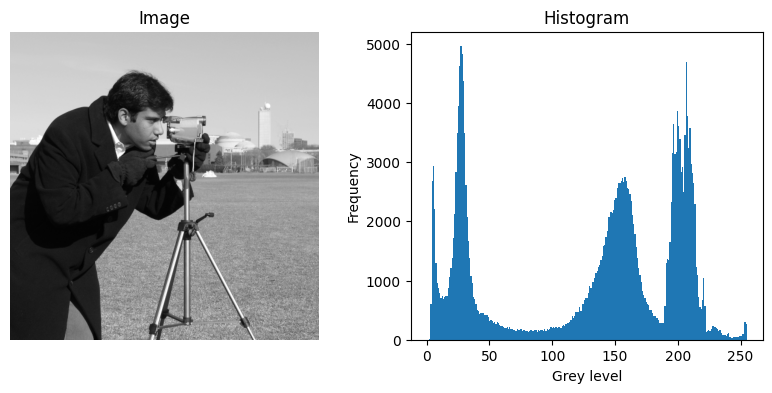

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

image = data.camera()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(image.flatten(), bins=256, range=(0,255))
plt.title("Histogram")
plt.xlabel("Grey level")
plt.ylabel("Frequency")

plt.show()

2-histogram equalision

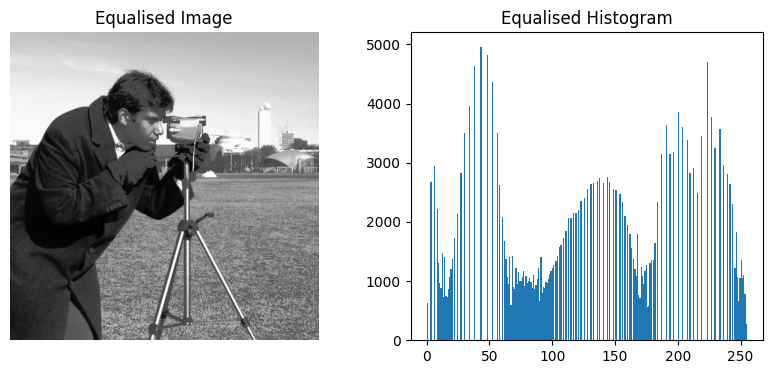

In [3]:
def hist_equalise(img):
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0,255))
    cdf = hist.cumsum()

    cdf_norm = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_norm = cdf_norm.astype(np.uint8)

    return cdf_norm[img]

equalised = hist_equalise(image)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(equalised, cmap='gray')
plt.title("Equalised Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(equalised.flatten(), bins=256, range=(0,255))
plt.title("Equalised Histogram")

plt.show()

3- smoothing


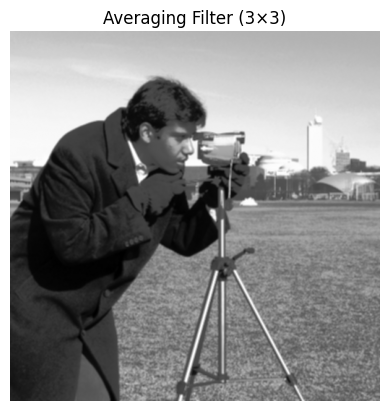

In [4]:
from scipy.ndimage import uniform_filter

smoothed = uniform_filter(equalised, size=3)

plt.imshow(smoothed, cmap='gray')
plt.title("Averaging Filter (3×3)")
plt.axis('off')
plt.show()

4- sharpping

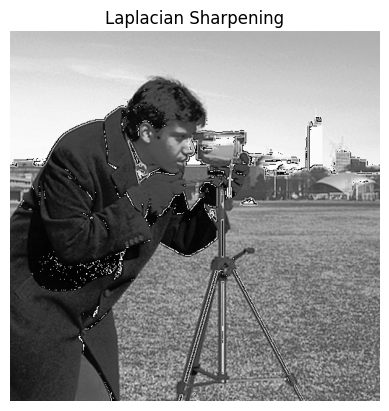

In [5]:
from scipy.ndimage import laplace

lap = laplace(smoothed)
sharpened = smoothed - lap

plt.imshow(sharpened, cmap='gray')
plt.title("Laplacian Sharpening")
plt.axis('off')
plt.show()

5- final comparsion

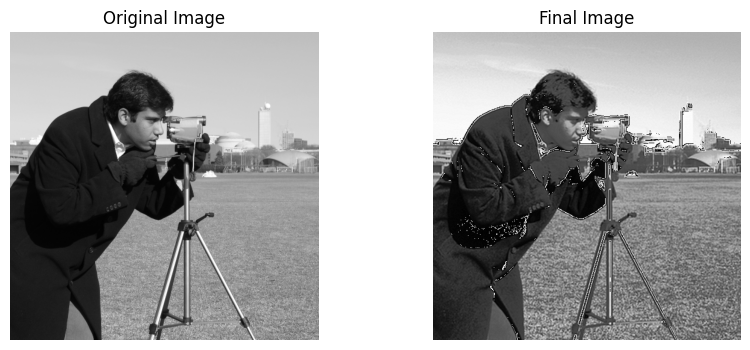

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharpened, cmap='gray')
plt.title("Final Image")
plt.axis('off')

plt.show()

1. Why does histogram equalisation sometimes over enhance images?
It can over increase contrast and amplify noise

2. Why is no single enhancement method sufficient in practice?
Different methods solve different problems, so combining them is necessary.

3. How does human perception influence a “good” enhancement?
Humans prefer images that look natural and visually clear.